# 資料前處理
由於 KNN impute 會比較花時間，可以跳到後面直接載入 parquet 檔案

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/Health_Dataset/health_dataset.csv")
df.drop(columns=[
    "ADM_RNO1",  # administrative record number
    "Province",  # province where the respondent resides
    "Health_region_ grouped",
], inplace=True)
df.columns

Index(['Gender', 'Marital_status', 'Household', 'Age', 'Worked_job_business',
       'Edu_level', 'Gen_health_state', 'Life_satisfaction',
       'Mental_health_state', 'Stress_level', 'Work_stress', 'Sense_belonging',
       'Weight_state', 'BMI_12_17', 'BMI_18_above', 'Sleep_apnea', 'High_BP',
       'High_cholestrol', 'Diabetic', 'Fatigue_syndrome', 'Mood_disorder',
       'Anxiety_disorder', 'Respiratory_chronic_con', 'Musculoskeletal_con',
       'Cardiovascular_con', 'Health_utility_indx', 'Pain_status',
       'Act_improve_health', 'Fruit_veg_con', 'Smoked', 'Tobaco_use',
       'weekly_alcohol', 'Cannabies_use', 'Drug_use', 'Total_active_time',
       'Total_physical_act_time', 'Other_physical_act_time',
       'Physical_vigorous_act_time', 'Work_hours ', 'working_status ',
       'Aboriginal_identity', 'Birth_country', 'Immigrant', 'Insurance_cover',
       'Food_security', 'Income_source', 'Total_income'],
      dtype='object')

In [2]:
# Life_satisfaction的97,98,99均無效
df.replace({"Life_satisfaction": [97,98,99]}, np.nan, inplace=True)
# 移除 life_satisfaction 缺漏的row
df.dropna(subset=["Life_satisfaction"], inplace=True)
# 在Worked_job_business中，6,7,8,9其實都算是無效輸入，合併為9
df.replace({"Worked_job_business": [6,7,8,9]}, 9, inplace=True)
# 合併Marital_status的6,9
df.replace({"Marital_status": [6,9]}, 9, inplace=True)
# 合併Gen_health_state的6,9
df.replace({"Gen_health_state": [6,9]}, np.nan, inplace=True)
# 合併Mental_health_state的7,8,9
df.replace({"Mental_health_state": [7,8,9]}, np.nan, inplace=True)
# 合併Stress_level的7,8
df.replace({"Stress_level": [7,8]}, np.nan, inplace=True)
# 合併Work_stress的6,7,8,9
df.replace({"Work_stress": [6,7,8,9]}, np.nan, inplace=True)
# 合併Sense_belonging的7,8,9
df.replace({"Sense_belonging": [7,8,9]}, np.nan, inplace=True)
# 合併Weight_state的6,7,8,9
df.replace({"Weight_state": [6,7,8,9]}, 9, inplace=True)
# 合併BMI欄位。一邊6另一邊就會是9，並且一題回答另一邊就會是6
def merge_bmi(row):
    if row["BMI_12_17"] == 9 or row["BMI_18_above"] == 9:
        return 9
    elif row["BMI_12_17"] in [1, 2] or row["BMI_18_above"] in [1, 2]:
        # 如果有一邊是 1 或 2，則設為相對應的值
        return row["BMI_12_17"] if row["BMI_12_17"] in [1, 2] else row["BMI_18_above"]
    else:
        # 如果有任何其他情況，報錯
        raise ValueError(f"Invalid BMI values: {row['BMI_12_17']}, {row['BMI_18_above']}")
df["BMI"] = df.apply(merge_bmi, axis=1)
df.drop(columns=["BMI_12_17", "BMI_18_above"], inplace=True)
# 合併Sleep_apnea的7,8
df.replace({"Sleep_apnea": [7,8]}, 8, inplace=True)
# 合併High_BP的7,8
df.replace({"High_BP": [7,8]}, 8, inplace=True)
# 合併High_cholestrol的6,7,8
df.replace({"High_cholestrol": [6,7,8]}, 8, inplace=True)
# 合併Diabetic的6,7,8
df.replace({"Diabetic": [6,7,8]}, 8, inplace=True)
# 合併Fatigue_syndrome的7,8
df.replace({"Fatigue_syndrome": [7,8]}, 8, inplace=True)
# 合併Mood_disorder的7,8
df.replace({"Mood_disorder": [7,8]}, 8, inplace=True)
# 合併 Anxiety_disorder 的7,8
df.replace({"Anxiety_disorder": [7,8]}, 8, inplace=True)
# 合併 Musculoskeletal_con 的6,9
df.replace({"Musculoskeletal_con": [6,9]}, 9, inplace=True)
# 合併 Act_improve_health 的6,7,8
df.replace({"Act_improve_health": [6,7,8]}, 8, inplace=True)
# 合併 Fruit_veg_con 的6,9
df.replace({"Fruit_veg_con": [6,9]}, np.nan, inplace=True)
# 只考慮有沒有抽菸。沒有人有 Smoked 但是 Tobaco_use 是 2(No)
# drop column smoked as unsure whether 996 valid skip means no smoking, not using this feature
df.drop(columns=["Smoked"], inplace=True)
df.replace({"Tobaco_use": [6,7,8,9]}, 9, inplace=True)
# 合併 weekly_alcohol 的6,7,8,9
# df.replace({"weekly_alcohol": [6,7,8,9]}, 9, inplace=True)
# drop column weekly alcohol as descriptions in data dictionary(1- Yes, 2- No, 6-9) does not aligh with real data(0-140, 996,999), not using this feature
df.drop(columns=["weekly_alcohol"], inplace=True)
# 合併 Cannabies_use 的6,7,8,9
df.replace({"Cannabies_use": [6,7,8,9]}, 9, inplace=True)
# 合併 Drug_use 的6,9
df.replace({"Drug_use": [6,9]}, 9, inplace=True)
# Total_active_time 的99996~99999全部無效
df.replace({"Total_active_time": [99996,99997,99998,99999]}, np.nan, inplace=True)
# Total_physical_act_time 的99996~99999全部無效
df.replace({"Total_physical_act_time": [99996,99997,99998,99999]}, np.nan, inplace=True)
# Physical_vigorous_act_time 的99996,99999無效
df.replace({"Physical_vigorous_act_time": [99996,99999]}, np.nan, inplace=True)
# Work_hours 的96,99無效
df.replace({"Work_hours ": [96,99]}, np.nan, inplace=True)
# 合併 working_status 的6,9
df.replace({"working_status ": [6,9]}, 9, inplace=True)
# 合併 Aboriginal_identity 的7,8,9
df.replace({"Aboriginal_identity": [7,8,9]}, 9, inplace=True)
# 合併 Food_security 的6,9
df.replace({"Food_security": [6,9]}, np.nan, inplace=True)

numeric_columns = [
    "Edu_level",
    "Gen_health_state",
    "Mental_health_state",
    "Stress_level",
    "Work_stress",
    "Sense_belonging",
    "Total_active_time",
    "Total_physical_act_time",
    "Other_physical_act_time",
    "Physical_vigorous_act_time",
    "Food_security",
    "Fruit_veg_con",
    "Total_income",
]

one_hot_columns = [
    "Gender",
    "Marital_status",
    "Household",
    "Age",
    "Worked_job_business",
    # "Life_satisfaction",
    "Weight_state",
    "BMI",
    "Sleep_apnea",
    "High_BP",
    "High_cholestrol",
    "Diabetic",
    "Fatigue_syndrome",
    "Mood_disorder",
    "Anxiety_disorder",
    "Respiratory_chronic_con",
    "Musculoskeletal_con",
    "Cardiovascular_con",
    "Health_utility_indx",
    "Pain_status",
    "Act_improve_health",
    "Tobaco_use",
    # "weekly_alcohol",
    "Cannabies_use",
    "Drug_use",
    "Work_hours ",
    "working_status ",
    "Aboriginal_identity",
    "Birth_country",
    "Immigrant",
    "Insurance_cover",
    "Income_source",
]

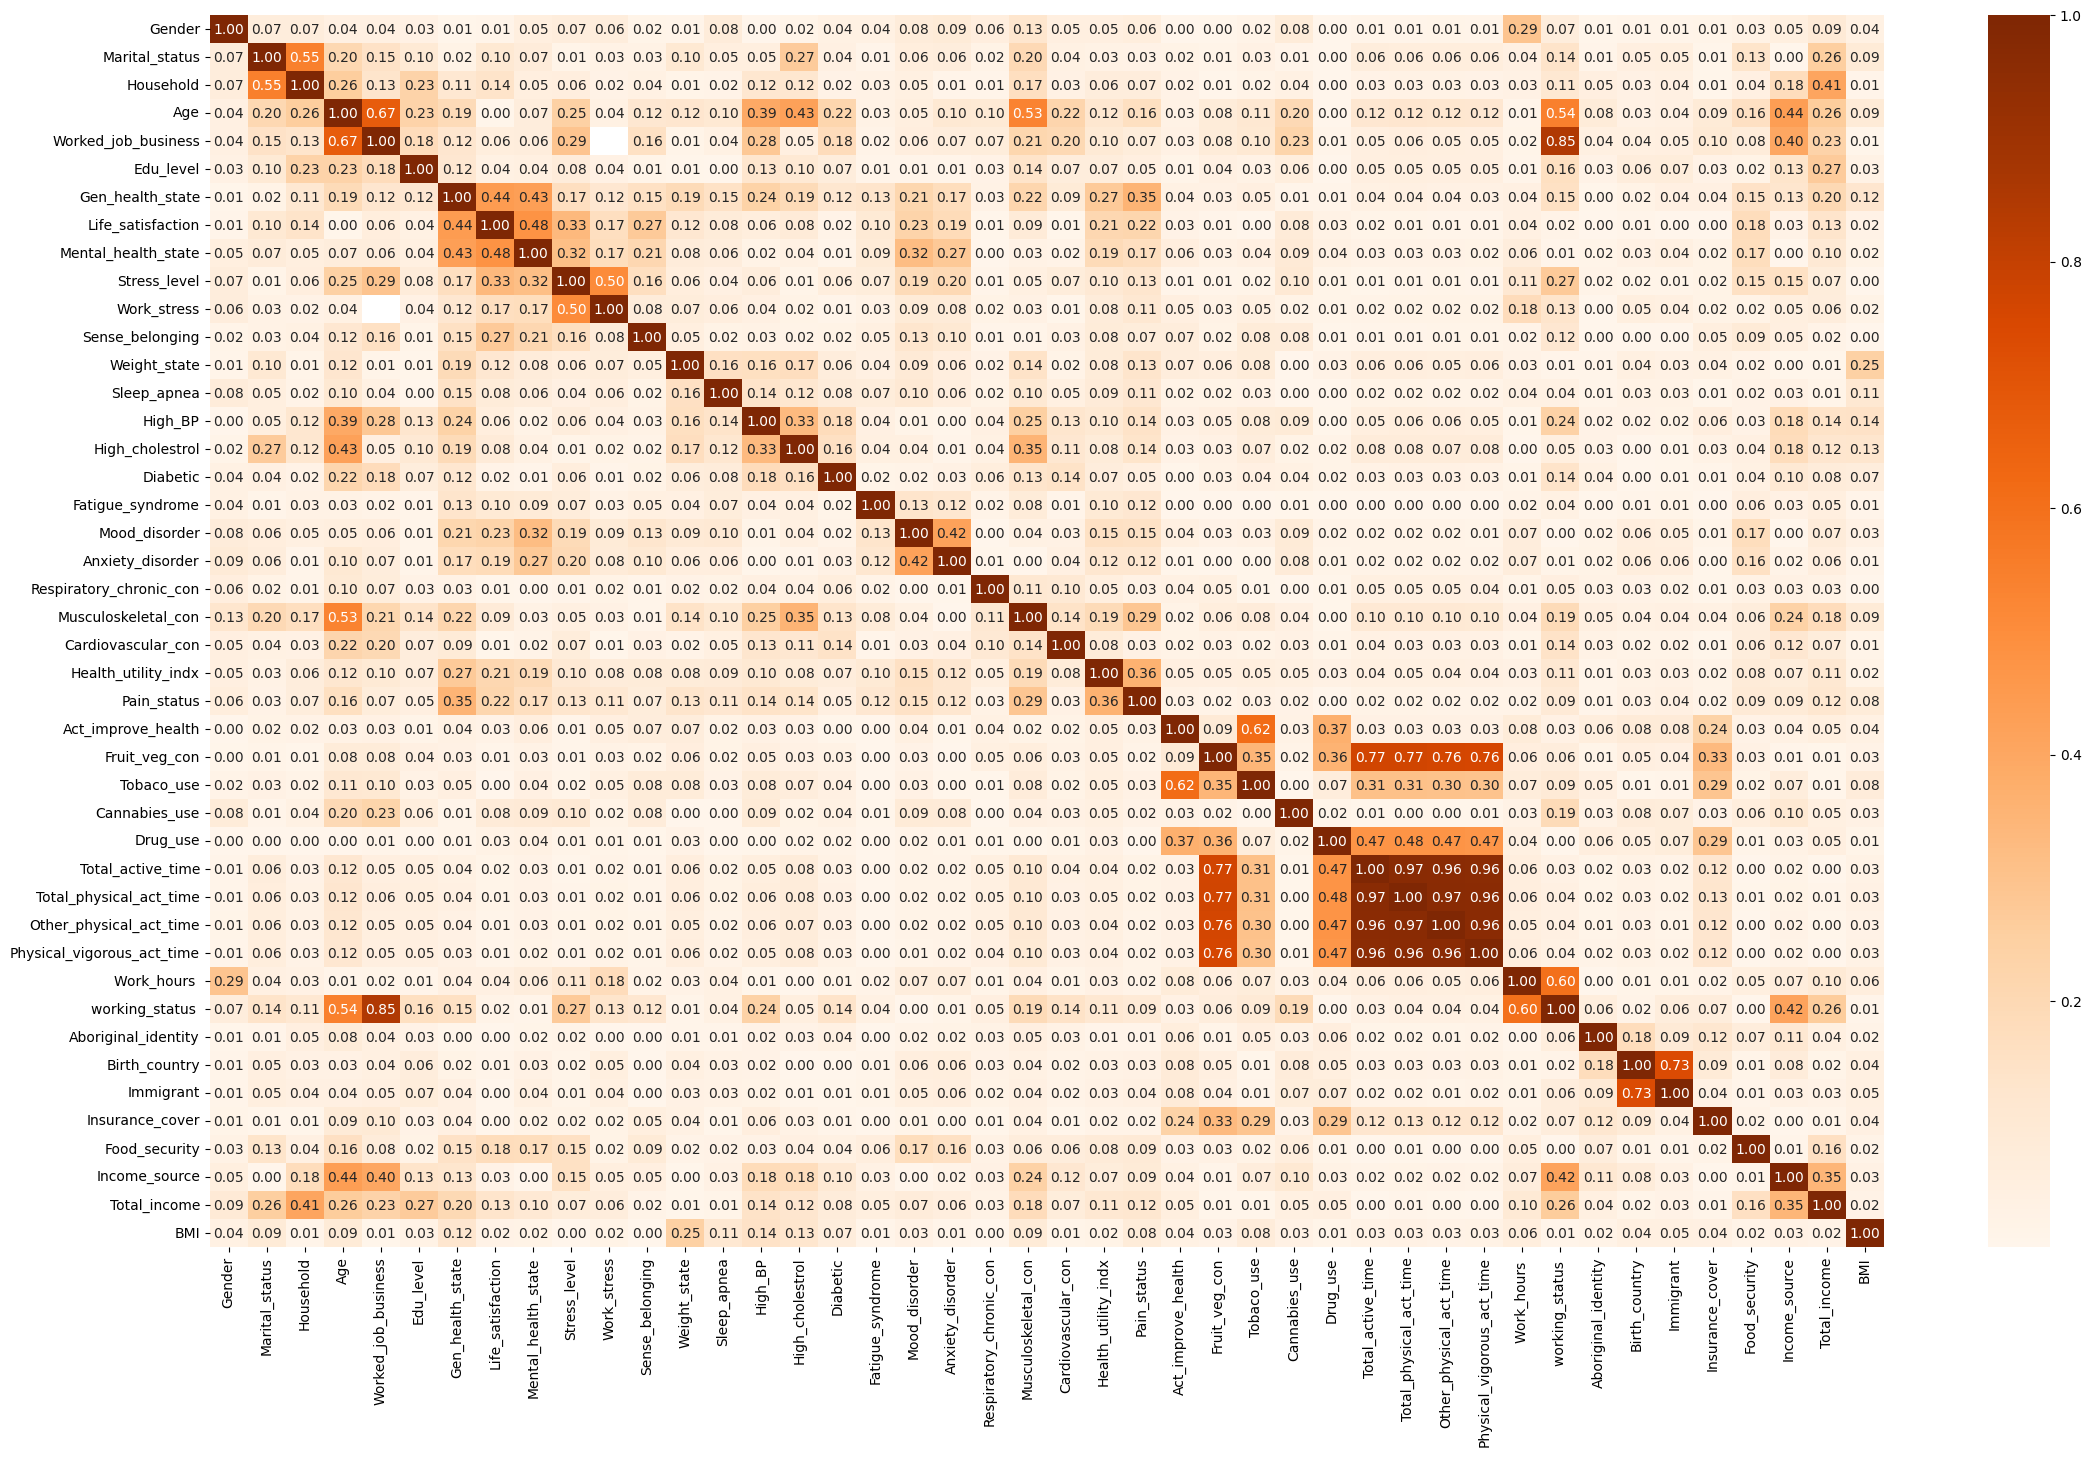

In [3]:
import seaborn as sns

plt.figure(figsize=(27, 16))
corr_matrix = df.corr(method='spearman').abs()
sns.heatmap(corr_matrix, annot=True, cmap='Oranges', fmt=".2f")
plt.show()

In [4]:
df = pd.get_dummies(df, drop_first=True, columns=one_hot_columns)

In [5]:
try:
   from sklearnex import patch_sklearn, config_context
   patch_sklearn()
except ImportError: pass
from contextlib import nullcontext
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

imputer = KNNImputer(n_neighbors=5, weights="distance")

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

scaler = StandardScaler()

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
df

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Work_stress,Sense_belonging,Fruit_veg_con,Total_active_time,Total_physical_act_time,...,Birth_country_9,Immigrant_2,Immigrant_9,Insurance_cover_2,Insurance_cover_6,Insurance_cover_7,Insurance_cover_8,Insurance_cover_9,Income_source_2,Income_source_9
0,-0.000906,0.563802,9.0,0.881354,-0.565478,-0.939196,-0.127853,-1.745466,-2.086782,-2.082262,...,False,True,False,False,False,False,False,False,False,False
1,-0.646272,0.563802,4.0,0.881354,0.417423,0.755871,1.097969,-1.745536,-2.086782,-2.082262,...,False,True,False,False,False,False,False,False,True,False
2,-1.291639,-0.394318,7.0,0.881354,0.417423,-0.939196,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False
3,-1.291639,0.563802,8.0,0.881354,0.417423,0.008524,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False
4,-0.000906,2.480043,0.0,2.943629,1.400324,1.633357,1.097969,0.573395,0.484533,0.485451,...,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108247,-1.291639,-0.394318,9.0,-0.149784,-0.565478,0.017276,1.097969,-1.745002,-2.086782,-2.082262,...,False,True,False,False,True,False,False,False,True,False
108248,-0.000906,0.563802,5.0,1.912491,1.400324,-0.939196,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,False,False
108249,-0.000906,-1.352439,9.0,0.881354,0.417423,0.245454,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,False,True
108250,-0.646272,0.563802,8.0,-0.149784,-0.565478,-0.702266,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False


In [6]:
from scipy.stats import pearsonr

corr_list = []
for col in df.columns:
    if col == "Life_satisfaction":
        continue
    corr, _ = pearsonr(df["Life_satisfaction"], df[col])
    corr_list.append((col, abs(corr)))
corr_list.sort(key=lambda x: abs(x[1]), reverse=True)
print(*list(enumerate(corr_list[:60])), sep="\n")

(0, ('Mental_health_state', np.float64(0.5033036106087687)))
(1, ('Gen_health_state', np.float64(0.4704832012523811)))
(2, ('Stress_level', np.float64(0.3404972161958582)))
(3, ('Health_utility_indx_2', np.float64(0.33591092479602563)))
(4, ('Sense_belonging', np.float64(0.2763559398103754)))
(5, ('Mood_disorder_2', np.float64(0.26809816218378957)))
(6, ('Pain_status_2', np.float64(0.2331868022450642)))
(7, ('Food_security', np.float64(0.22548617762265294)))
(8, ('Anxiety_disorder_2', np.float64(0.21416396647305128)))
(9, ('Work_stress', np.float64(0.19896348775773173)))
(10, ('Marital_status_2', np.float64(0.1865692324004391)))
(11, ('Household_2', np.float64(0.15220296891510543)))
(12, ('Fatigue_syndrome_2', np.float64(0.14777541956071621)))
(13, ('Total_income', np.float64(0.1378626645671187)))
(14, ('Cannabies_use_2', np.float64(0.13276853273535352)))
(15, ('Weight_state_3', np.float64(0.1228762961958718)))
(16, ('Respiratory_chronic_con_2', np.float64(0.11915712181410956)))
(17, (

In [7]:
df.to_parquet("data/Health_Dataset/health_dataset.parquet", index=False, compression="lz4")

# 載入已經整理好的 parquet 檔案

In [1]:
try:
    from sklearnex import patch_sklearn, config_context
    patch_sklearn()
except ImportError: pass
from contextlib import nullcontext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/Health_Dataset/health_dataset.parquet")

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [9]:
from scipy.stats import pearsonr

corr_list = []
for col in df.columns:
    if col == "Life_satisfaction":
        continue
    corr, _ = pearsonr(df["Life_satisfaction"], df[col])
    corr_list.append((col, abs(corr)))
corr_list.sort(key=lambda x: abs(x[1]), reverse=True)
print(*list(enumerate(corr_list[:60])), sep="\n")

(0, ('Mental_health_state', np.float64(0.5033036106087687)))
(1, ('Gen_health_state', np.float64(0.4704832012523811)))
(2, ('Stress_level', np.float64(0.3404972161958582)))
(3, ('Health_utility_indx_2', np.float64(0.33591092479602563)))
(4, ('Sense_belonging', np.float64(0.2763559398103754)))
(5, ('Mood_disorder_2', np.float64(0.26809816218378957)))
(6, ('Pain_status_2', np.float64(0.2331868022450642)))
(7, ('Food_security', np.float64(0.22548617762265294)))
(8, ('Anxiety_disorder_2', np.float64(0.21416396647305128)))
(9, ('Work_stress', np.float64(0.19896348775773173)))
(10, ('Marital_status_2', np.float64(0.1865692324004391)))
(11, ('Household_2', np.float64(0.15220296891510543)))
(12, ('Fatigue_syndrome_2', np.float64(0.14777541956071621)))
(13, ('Total_income', np.float64(0.1378626645671187)))
(14, ('Cannabies_use_2', np.float64(0.13276853273535352)))
(15, ('Weight_state_3', np.float64(0.1228762961958718)))
(16, ('Respiratory_chronic_con_2', np.float64(0.11915712181410956)))
(17, (

In [10]:
# df = df[df.columns.difference(list(c[0] for c in corr_list[50:]))]

<Axes: xlabel='Life_satisfaction'>

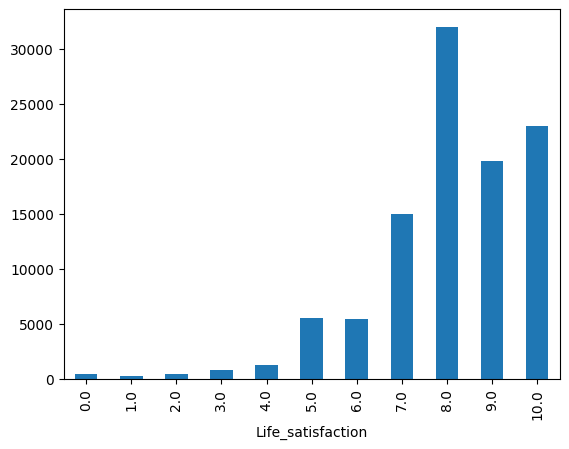

In [1]:
df["Life_satisfaction"].value_counts().sort_index().plot(kind="bar")

In [2]:
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Life_satisfaction"])
y = df["Life_satisfaction"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    smote = SMOTETomek(n_jobs=-1, random_state=42)
    X_train_sample, y_train_sample = smote.fit_resample(X_train, y_train)

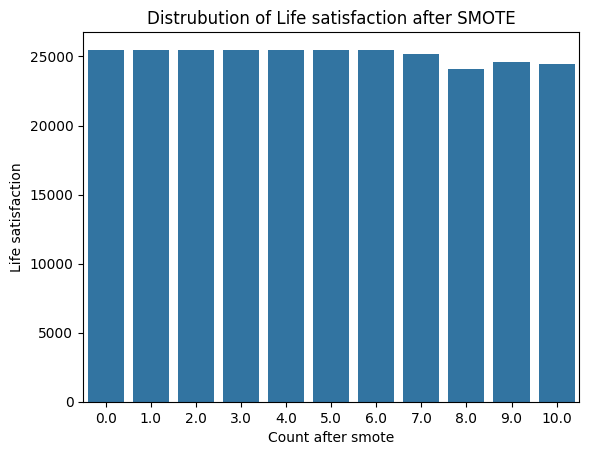

In [13]:
import seaborn as sns

sns.countplot(x=y_train_sample)
plt.xlabel("Count after smote")
plt.ylabel("Life satisfaction")
plt.title("Distrubution of Life satisfaction after SMOTE")
plt.show()

score for random guessing

In [14]:
from sklearn.metrics import mean_absolute_error

y_mean = np.full_like(y_test, np.mean(y_train_sample))
y_pred = np.clip(y_mean, 0, 10)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 3.252959118654987


score of logisticregression

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    lr = LogisticRegression(max_iter=1000, n_jobs=-1)
    lr.fit(X_train_sample, y_train_sample)
    y_pred = np.clip(lr.predict(X_test), 0, 10)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 1.537840565085772


score of random forest

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    rf = RandomForestRegressor(oob_score=True, n_jobs=-1, random_state=42)
    rf.fit(X_train_sample, y_train_sample)
    y_pred = np.clip(rf.predict(X_test), 0, 10)
    oob_score = rf.oob_score_
    # Perform cross-validation
    cv_scores = cross_val_score(rf, X_train_sample, y_train_sample, cv=5, scoring='r2')

print("MAE:", mean_absolute_error(y_test, y_pred))
print(f'Out-of-Bag Score: {oob_score}')
print(f'R-squared: {r2_score(y_test, y_pred)}')
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Mean R² score: {cv_scores.mean()}")

MAE: 1.0106133669929707
Out-of-Bag Score: 0.9204637074506572
R-squared: 0.33543835430066604
Cross-validation R² scores: [ 0.43119744  0.43311911 -3.90139549 -1.8396961  -1.94961717]
Mean R² score: -1.3652784438060024


score of lassocv

In [17]:
from sklearn.linear_model import LassoCV

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    lasso = LassoCV(cv=5)
    lasso.fit(X_train_sample, y_train_sample)
    y_pred = np.clip(lasso.predict(X_test), 0, 10)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 1.2559231315534891


In [18]:
# Get feature names
feature_names = X_train_sample.columns
# Create a Series of coefficients
coef_series = pd.Series(lasso.coef_, index=feature_names)
# Show non-zero coefficients (i.e., selected features)
pd.set_option("display.max_rows", None)
important_features = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)
print("\nImportant features selected by LassoCV:")
print(important_features)


Important features selected by LassoCV:
Age_5                        -1.389215
Immigrant_2                  -0.987305
Drug_use_9                   -0.946011
Marital_status_2             -0.914609
Tobaco_use_9                 -0.861594
Age_4                        -0.840984
Marital_status_9             -0.789042
Drug_use_2                   -0.779654
Birth_country_2              -0.755113
Age_3                        -0.689439
Weight_state_2               -0.667089
Work_hours _35.0             -0.653383
Tobaco_use_2                 -0.647032
Work_hours _40.0             -0.645205
working_status _9            -0.600885
BMI_2.0                      -0.599371
Gen_health_state             -0.572919
Insurance_cover_2            -0.561538
Household_2                  -0.547405
High_cholestrol_8            -0.512201
Pain_status_2                -0.487301
BMI_9.0                      -0.485063
Work_hours _50.0             -0.477398
Act_improve_health_8         -0.471995
Weight_state_3         

score of MLP

In [5]:
from pathlib import Path
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.optim.lr_scheduler import LRScheduler
from torch.utils.data import Dataset, DataLoader
from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler

from sklearn.metrics import r2_score

from utils.logging import log, job_progress

### 超參數設定 ###

batch_size = 64
epochs = 20
# 模型的 checkpoint 儲存目錄
save_dir = Path("ckpt")
# 如果要從上次的進度繼續
load_path = None  # Path("ckpt/...")
# 多久儲存一次 checkpoint 並檢查最佳 loss
checkpoint_interval = 3

### 資料 ###

class HealthDataset(Dataset):
    def __init__(self, X: pd.DataFrame, y: pd.Series):
        self.X = torch.tensor(X.astype(float).values, dtype=torch.float32)
        self.y = torch.tensor(y.astype(float).values, dtype=torch.float32).unsqueeze(1)
        assert len(self.X) == len(self.y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### 模型 ###

class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### Checkpoint ###

@dataclass
class Checkpoint:
    start_epoch: int
    best_loss: float
    model: nn.Module
    optimizer: Optimizer
    lr_scheduler: LRScheduler
    amp_scaler: GradScaler


def save_checkpoint(
    checkpoint: Checkpoint,
    save_dir: Path,
):
    save_path = save_dir / f"checkpoint_epoch_{checkpoint.start_epoch}.pth"
    torch.save(
        {
            "start_epoch": checkpoint.start_epoch,
            "best_loss": checkpoint.best_loss,
            "model": checkpoint.model.state_dict(),
            "optimizer": checkpoint.optimizer.state_dict(),
            "lr_scheduler": checkpoint.lr_scheduler.state_dict(),
            "amp_scaler": checkpoint.amp_scaler.state_dict(),
        },
        save_path,
    )


def load_checkpoint(
    checkpoint: Checkpoint,
    save_path: Path,
):
    ckpt = torch.load(save_path, weights_only=True)
    checkpoint.model.load_state_dict(ckpt["model"])
    checkpoint.optimizer.load_state_dict(ckpt["optimizer"])
    checkpoint.lr_scheduler.load_state_dict(ckpt["lr_scheduler"])
    checkpoint.amp_scaler.load_state_dict(ckpt["amp_scaler"])
    return (
        ckpt["start_epoch"] + 1,
        ckpt["best_loss"],
    )

### 評估 ###

def evaluate(model: nn.Module, dataloader: DataLoader, device: torch.device):
    model.eval()
    total_mae = 0.0
    total_r2 = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            with autocast(device.type):
                outputs = model(X)
                loss = F.l1_loss(outputs, y)
            total_mae += loss.item()
            r2 = r2_score(y.cpu().numpy(), outputs.cpu().numpy())
            total_r2 += r2

    return total_mae / len(dataloader), total_r2 / len(dataloader)

### 訓練 ###

def train_mlp_main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    start_epoch = 1
    best_loss = float("inf")
    model = MLP(input_dim=X_train_sample.shape[1], output_dim=1).to(device)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )
    amp_scaler = GradScaler(device=device.type)

    if load_path:
        start_epoch, best_loss = load_checkpoint(Checkpoint(
            start_epoch=start_epoch,
            best_loss=best_loss,
            model=model,
            optimizer=optimizer,
            lr_scheduler=scheduler,
            amp_scaler=amp_scaler,
        ), load_path)

    save_dir.mkdir(parents=True, exist_ok=True)

    # Initialize DataLoader
    train_dataloader = DataLoader(
        HealthDataset(X_train_sample, y_train_sample), batch_size=batch_size, shuffle=True
    )
    test_dataloader = DataLoader(
        HealthDataset(X_test, y_test), batch_size=batch_size, shuffle=False
    )

    progress = job_progress()
    prog_epoch = progress.add_task("Epoch", completed=start_epoch-1, total=start_epoch -1 +epochs)

    with progress:
        for epoch in range(start_epoch, start_epoch + epochs):
            model.train()
            total_loss = 0.0

            prog_batch = progress.add_task("Batch", total=len(train_dataloader))
            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)

                optimizer.zero_grad()
                with autocast(device.type):
                    outputs = model(x)
                    loss = criterion(outputs, y)
                    total_loss += loss.item()
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                amp_scaler.step(optimizer)
                amp_scaler.update()
                progress.advance(prog_batch)
            progress.remove_task(prog_batch)
            scheduler.step()

            total_loss /= len(train_dataloader)
            log.info(f"Epoch {epoch}: Loss = {total_loss:.4f}")

            # Validation
            if epoch % checkpoint_interval == 0 or epoch == start_epoch + epochs - 1:
                val_loss, _ = evaluate(model, test_dataloader, device)
                log.info(f"Epoch {epoch}: Val Loss: {val_loss:.4f}")

                if val_loss < best_loss:
                    best_loss = val_loss
                    log.info(f"New best loss: {best_loss:.4f} saved at {epoch}")
                else:
                    log.info(f"Checkpoint saved at epoch {epoch} with loss {val_loss:.4f}")
                save_checkpoint(
                    Checkpoint(
                        start_epoch=epoch,
                        best_loss=best_loss,
                        model=model,
                        optimizer=optimizer,
                        lr_scheduler=scheduler,
                        amp_scaler=amp_scaler,
                    ),
                    save_dir,
                )
            progress.advance(prog_epoch)
        progress.remove_task(prog_epoch)
    log.info(f"Training complete. Best loss: {best_loss:.4f}")

In [6]:
train_mlp_main()

Output()

[01:08:42] INFO     Epoch 1: Loss = 1.2461                                                        ]8;id=893799;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=389030;file:///tmp/ipykernel_54824/2138541617.py#178\178]8;;\

[01:08:47] INFO     Epoch 2: Loss = 0.9942                                                        ]8;id=828152;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=115749;file:///tmp/ipykernel_54824/2138541617.py#178\178]8;;\

[01:08:53] INFO     Epoch 3: Loss = 0.9052                                                        ]8;id=622682;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=209680;file:///tmp/ipykernel_54824/2138541617.py#178\178]8;;\

[01:08:54] INFO     Epoch 3: Val Loss: 1.0342                                                     ]8;id=917776;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=243055;file:///tmp/ipykernel_54824/2138541617.py#183\183]8;;\

...

[01:10:31] INFO     Epoch 19: Loss = 0.5730                                                       ]8;id=593267;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=151152;file:///tmp/ipykernel_54824/2138541617.py#178\178]8;;\

[01:10:37] INFO     Epoch 20: Loss = 0.5701                                                       ]8;id=543436;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=799088;file:///tmp/ipykernel_54824/2138541617.py#178\178]8;;\

           INFO     Epoch 20: Val Loss: 1.0459                                                    ]8;id=289985;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=669521;file:///tmp/ipykernel_54824/2138541617.py#183\183]8;;\

           INFO     Checkpoint saved at epoch 20 with loss 1.0459                                 ]8;id=150554;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=604854;file:///tmp/ipykernel_54824/2138541617.py#189\189]8;;\

           INFO     Training complete. Best loss: 1.0342                                          ]8;id=934566;file:///tmp/ipykernel_54824/2138541617.py\2138541617.py]8;;\:]8;id=596213;file:///tmp/ipykernel_54824/2138541617.py#203\203]8;;\

如果想要從已經存檔的模型進行推論的話，執行這個

In [6]:
model_path = save_dir / "best.pth"  # 改成你想要的檔名

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(input_dim=X_train_sample.shape[1], output_dim=1).to(device)
model.load_state_dict(torch.load(model_path, weights_only=False)["model"])
test_dataloader = DataLoader(
    HealthDataset(X_test, y_test), batch_size=batch_size, shuffle=False
)

total_mae, total_r2 = evaluate(model, test_dataloader, device)
print(f"Test MAE: {total_mae:.4f}, Test R2: {total_r2:.4f}")

Test MAE: 1.0342, Test R2: 0.2436
